# Windowing and Resampling

In this notebook, we are going to investigate how to use `rasterio` to load a cropped and resized area of interest (AOI) out of a raster. These functionalities allow us to perform useful pre-processing operations like:

- Cutting the AOI out of the provided tile.
- Resample or downsample a band raster to match the desired analysis resolution algorithmically.

When we perform a resampling, we need to take into consideration the typo of variable we are using in the decision of the algorithm.

In [2]:
# Configure the .env variable with your authentication values.
from dotenv import load_dotenv

load_dotenv();

In [3]:
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio import transform, warp
from rasterio.enums import Resampling
from rasterio.profiles import Profile
from rasterio.transform import rowcol, xy
from rasterio.windows import from_bounds

As a reference tile, we are going to use a region of Andalusia (Spain). We can specify the bounding box we are interested in inspecting, but it will very hardly perfectly match a tile generated from satellite imagery.

In [5]:
href_andalusia = "s3://eodata/Sentinel-2/MSI/L2A_N0500/2022/12/27/S2B_MSIL2A_20221227T111359_N0510_R137_T30STG_20240807T153102.SAFE/GRANULE/L2A_T30STG_A030336_20221227T111439/IMG_DATA/R10m/T30STG_20221227T111359_B02_10m.jp2"

## Windowing

In [6]:
with rasterio.open(href_andalusia) as src:
    data_tile = src.read(1)
    bounds_tile = src.bounds
    crs = src.crs

In [7]:
print(crs)
print(bounds_tile)

EPSG:32630
BoundingBox(left=199980.0, bottom=4090200.0, right=309780.0, top=4200000.0)


This scene has been obtained by using the following bounding box in the STAC filter:

In [8]:
bounds_aoi = [
    -6.362565950090263,
    37.00620706676072,
    -5.798434049909736,
    37.45839293323928,
]

To understand if this bounding box is the same as the recovered tile, we first have to convert them to the same reference system.

Our bounding box is specified in terms of **latitude and longitude** coordinates, i.e. in the **geographic coordinate systems** defined by the [EPSG:4326](https://epsg.io/4326). From the previous lines, we can see that the raster is instead defined in the [EPSG:32630](http://epsg.io/32630) system. Despite the two systems having the same datum, they are intrinsically different. The former does not use any reprojection, a system used by the GPS but not suited to compute distances. The reason is that the degrees to meters conversion is not constant and varies from the equation to the poles. To solve this issue, *we need to reproject the 3D model of the Earth into a Cartesian plane*. In particular, we can have different reprojections, each valid only in a narrow band around the reprojection point; transforming an ellipsoid into a planar object inevitably introduces distortions. The **EPSG:32630** is exactly a reprojection that is accurate in the neighborhood of our AOI.

So, we first need to convert the obtained bounds of the tile into our **EPSG:4326**. To do so, we can use the `rasterio.warp` package, which provides utilities for raster warping and reprojection:

In [9]:
bounds_tile_deg = warp.transform_bounds(crs, "EPSG:4326", *bounds_tile)
bounds_tile_deg

(-6.411972478670402, 36.910119161131085, -5.13602504583506, 37.927680432889204)

To interpret this result, we need to recall that a bounding box is specified by defining the (lat, lon) pair for the point on the bottom-left and those for the point on the top-right of our parallelepiped. Since the coordinates of our AoI are higher than the ones of the tile for the west-south, and lower for the east-north, our AOI is fully contained in the tile.

Let's first visualize the original tile:

In [10]:
def robust_plot(data, bounds) -> None:
    """
    Plot the provided data with the Viridis cmap and min/max values given
    by the 2nd and 98th percentiles of the data.
    """
    vmin, vmax = np.percentile(data, [2, 98])
    left, bottom, right, top = bounds
    plt.imshow(
        data,
        vmin=vmin,
        vmax=vmax,
        extent=[left, right, bottom, top],
        cmap="viridis",
    )

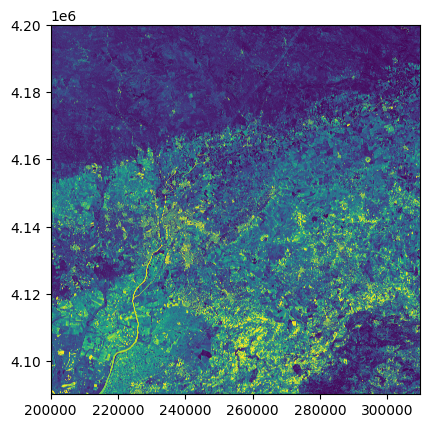

In [11]:
bounds_tile_list = [
    bounds_tile.left,
    bounds_tile.bottom,
    bounds_tile.right,
    bounds_tile.top,
]
robust_plot(data_tile, bounds_tile_list)

Now we want to only download the cropped AOI from the STAC database. When our computational resources are limited this helps us in reducing the required burden.

In [14]:
@dataclass
class ResamplingStrategy:
    factor: float = 1
    method: Resampling = Resampling.nearest

    def get_factor(self) -> float:
        return self.factor

    def get_method(self) -> Resampling:
        return self.method


def get_scene(
    item_path: str,
    window_bbox: BBox | None = None,  # EPSG: 4326
    resampling_strategy: ResamplingStrategy = ResamplingStrategy(),
) -> np.ndarray:

    window = None

    resampling_factor = resampling_strategy.get_factor()
    resampling_method = resampling_strategy.get_method()

    with rasterio.open(item_path) as src:
        if window_bbox is not None:
            # Transform from degree to meters.
            left, bottom, right, top = warp.transform_bounds(
                "EPSG:4326", src.crs, *window_bbox
            )

            window = from_bounds(
                left=left,
                bottom=bottom,
                right=right,
                top=top,
                transform=src.transform,
            )

        # Height and width of the output shape are influenced by cropping and by
        # resampling.
        height = int((window.height if window else src.height) * resampling_factor)
        width = int((window.width if window else src.width) * resampling_factor)

        # An output shape is always created and used inside the read method, so it should be ok to always set it here,
        # even with the original size.
        # https://github.com/rasterio/rasterio/blob/4e5bce88ea3c84b41a394244fe1cad6a5b8eb854/rasterio/_io.pyx#L544-L547
        data = src.read(
            1,
            window=window,
            out_shape=(height, width),
            resampling=resampling_method,
        )
    return data

In [15]:
scene = get_scene(href_andalusia, bounds_aoi)

We can now reconvert the AOI from the geographic reference system in degrees into the more familiar Cartesian system:

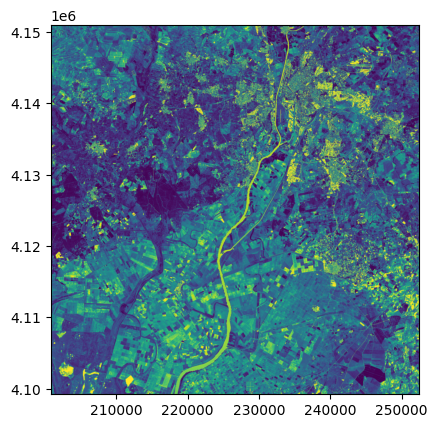

In [16]:
bounds_aoi_m = warp.transform_bounds("EPSG:4326", "EPSG:32630", *bounds_aoi)
robust_plot(scene, bounds_aoi_m)

We can see that even though we specified the same length for our AOI in both vertical and horizontal directions, the conversion inevitabely introduced some error and the shape of our raster is not squared:

In [19]:
scene.shape

(5181, 5169)

While the Sentinel-2 tile was perfectly squared:

In [21]:
data_tile.shape

(10980, 10980)

## Resampling

Let's investigate how to perform resampling of the dataset to algorithmically increase or decrease the resolution. Given that we are working with radiance, a continuous variable, we can use a bilinear interpolation method to increase the number of points in the same bounding box:

In [22]:
resampling = ResamplingStrategy(2, Resampling.bilinear)
scene_oversampled = get_scene(href_andalusia, bounds_aoi, resampling)

As expected, the number of points now doubled:

In [23]:
scene_oversampled.shape

(10362, 10338)

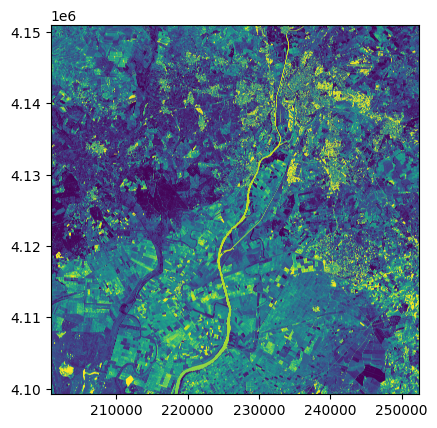

In [24]:
robust_plot(scene_oversampled, bounds_aoi_m)

Not that having performed the resampling, we should also reflect this change in pixel to meter size in the affine transformation of the GeoTIFF image.

We can now perform an upscaling reducing the resolution of the raster:

In [25]:
resampling = ResamplingStrategy(1 / 32, Resampling.bilinear)
scene_undersampled = get_scene(href_andalusia, bounds_aoi, resampling)

In [26]:
scene_undersampled.shape

(161, 161)

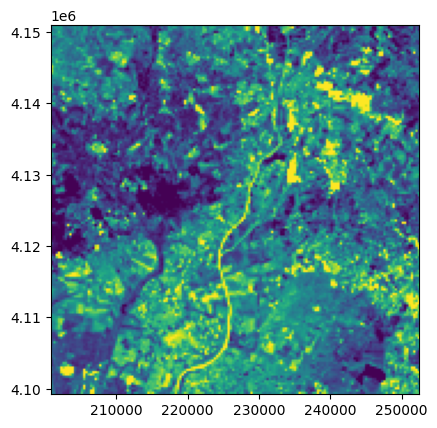

In [27]:
robust_plot(scene_undersampled, bounds_aoi_m)

## Affine Transformation Analysis 

In [28]:
from rasterio.windows import transform as window_transform

In [29]:
with rasterio.open(href_andalusia) as src:
    crs = src.crs
    transform = src.transform

window_bbox = bounds_aoi

# Transform from degree to meters.
left, bottom, right, top = warp.transform_bounds("EPSG:4326", crs, *window_bbox)

window = from_bounds(
    left=left,
    bottom=bottom,
    right=right,
    top=top,
    transform=transform,
)

In [30]:
transform

Affine(10.0, 0.0, 199980.0,
       0.0, -10.0, 4200000.0)

In [31]:
print(bounds_tile)

BoundingBox(left=199980.0, bottom=4090200.0, right=309780.0, top=4200000.0)


In [32]:
cropped_transform = window_transform(window, transform)

In [33]:
cropped_transform

Affine(10.0, 0.0, np.float64(200788.7171578621),
       0.0, -10.0, np.float64(4151036.8791220747))

In [34]:
bounds_aoi_m

(200788.7171578621, 4099222.676910201, 252483.18081873987, 4151036.8791220747)

## Memory Effort Analysis

Given the high number of images we are going to use and the limited resources I have available, it can be interesting to estimate the overall memory requirement.

What we will have, for each scene, is:

- 10 bands at 10m resolution with reflectance values.
- 1 band at 10m resolution with the Scene CLassification (SCL).

So, we will have 10 bands with each pixel requiring 2 bytes (`uint16`) and 1 band with pixels requiring 1 bytes each. To limit the disk requirement, we limited each season to have at maximum of 10 scenes. We can approximate and assume all the pixel require 2 bytes and obtain:

In [35]:
disk_requirement = scene.shape[0] * scene.shape[1] * 2 * 11 / 1024 / 1024 / 1024
print(f"Disk requirement for single image: {disk_requirement} GB")
print(f"Disk requirement total: {disk_requirement * 40} GB")

Disk requirement for single image: 0.5487100761383772 GB
Disk requirement total: 21.948403045535088 GB
